In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_ua = pd.read_csv('Ukraine.csv')

X = df_ua.drop(columns=['price'])
y = df_ua['price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Розмір навчальної вибірки: {X_train.shape[0]} квартир")
print(f"Розмір тестової вибірки: {X_test.shape[0]} квартир")

Розмір навчальної вибірки: 6822 квартир
Розмір тестової вибірки: 1706 квартир


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

models_ua = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_state=42)
}


results_ua = []

print("Тренуємо моделі для регіонів України...\n")

for name, model in models_ua.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results_ua.append({
        "Модель": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })
    
df_results_ua = pd.DataFrame(results_ua).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ ДЛЯ УКРАЇНИ:")
print(df_results_ua)

Тренуємо моделі для регіонів України...

ФІНАЛЬНІ РЕЗУЛЬТАТИ ПОРІВНЯННЯ ДЛЯ УКРАЇНИ:
             Модель  R2 Score  MAE ($)  RMSE ($)
0          LightGBM    0.7187   214.12    286.86
1     Random Forest    0.7064   217.62    293.08
2          CatBoost    0.7057   219.58    293.40
3  Ridge Regression    0.5934   268.79    344.90


In [6]:
from sklearn.model_selection import GridSearchCV

lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 15],
    'random_state': [42]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'random_state': [42],
    'n_jobs': [-1] 
}


print("=== Оптимізація LightGBM... ===")
lgb_grid = GridSearchCV(
    estimator=LGBMRegressor(),
    param_grid=lgb_param_grid,
    cv=3, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
lgb_grid.fit(X_train, y_train)

print("\n=== Оптимізація Random Forest... ===")
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(),
    param_grid=rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

best_lgb = lgb_grid.best_estimator_
best_rf = rf_grid.best_estimator_

models = {
    'Optimized LightGBM': best_lgb,
    'Optimized Random Forest': best_rf
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Модель': name,
        'R2 Score': round(r2, 4),
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2)
    })

df_results = pd.DataFrame(results)
print("\n=== ФІНАЛЬНІ РЕЗУЛЬТАТИ ПІСЛЯ ТЮНІНГУ ===")
print(df_results.to_markdown(index=False))

print("\nНайкращі параметри LightGBM:", lgb_grid.best_params_)
print("Найкращі параметри Random Forest:", rf_grid.best_params_)

=== Оптимізація LightGBM... ===
Fitting 3 folds for each of 81 candidates, totalling 243 fits

=== Оптимізація Random Forest... ===
Fitting 3 folds for each of 36 candidates, totalling 108 fits

=== ФІНАЛЬНІ РЕЗУЛЬТАТИ ПІСЛЯ ТЮНІНГУ ===
| Модель                  |   R2 Score |   MAE ($) |   RMSE ($) |
|:------------------------|-----------:|----------:|-----------:|
| Optimized LightGBM      |     0.7149 |    216.37 |     288.81 |
| Optimized Random Forest |     0.7065 |    216.99 |     293.04 |

Найкращі параметри LightGBM: {'learning_rate': 0.05, 'max_depth': 15, 'n_estimators': 300, 'num_leaves': 31, 'random_state': 42}
Найкращі параметри Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300, 'n_jobs': -1, 'random_state': 42}


=== Оптимізація Ridge (L2)... ===
=== Оптимізація Lasso (L1)... ===

=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===
Ridge L2 -> Найкращий alpha: 31.6228 | R2: 0.5937 | MAE: $268.61
Lasso L1 -> Найкращий alpha: 0.3162 | R2: 0.5939 | MAE: $268.49


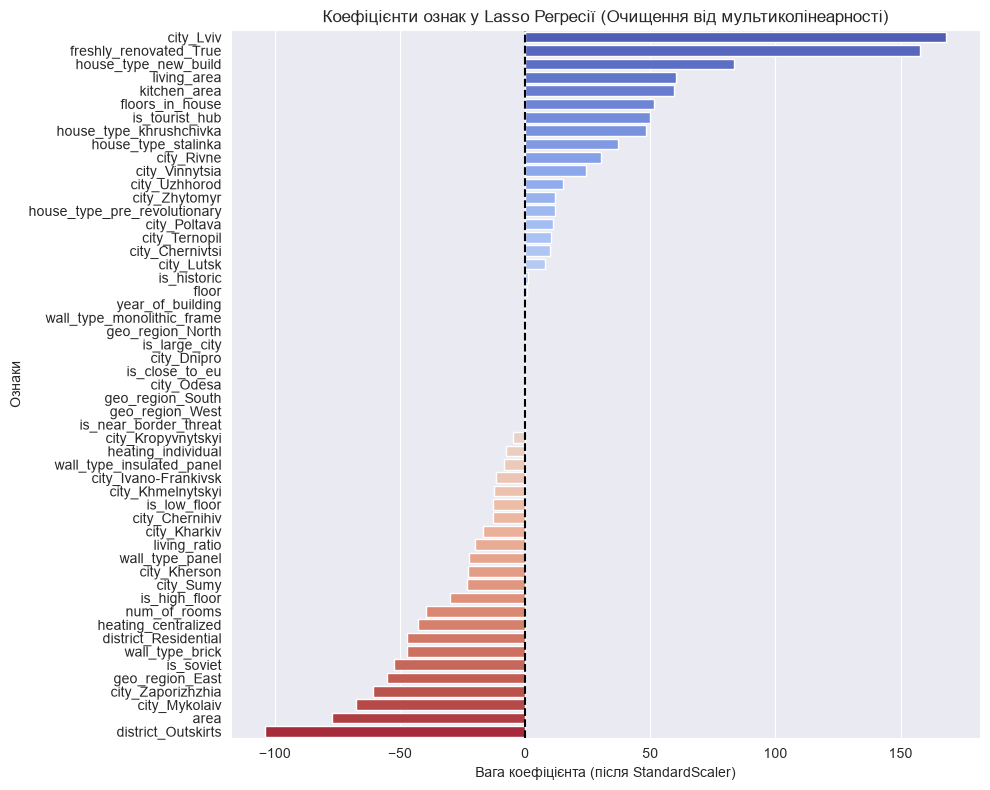


❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): ['wall_type_monolithic_frame', 'geo_region_North', 'is_large_city', 'city_Dnipro', 'is_close_to_eu', 'city_Odesa', 'geo_region_South', 'geo_region_West', 'is_near_border_threat']


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. СТВОРЕННЯ ПАЙПЛАЙНІВ З МАСШТАБУВАННЯМ
# ==========================================

# Налаштовуємо сітку для параметра alpha (сила регуляризації)
param_grid = {'model__alpha': np.logspace(-3, 3, 13)}

# Пайплайн для Ridge
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

# Пайплайн для Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42, max_iter=10000)) # збільшено max_iter для збіжності
])

# ==========================================
# 2. ЗАПУСК GRID SEARCH ДЛЯ ОБОХ МОДЕЛЕЙ
# ==========================================

print("=== Оптимізація Ridge (L2)... ===")
ridge_grid = GridSearchCV(ridge_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)

print("=== Оптимізація Lasso (L1)... ===")
lasso_grid = GridSearchCV(lasso_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
lasso_grid.fit(X_train, y_train)

# ==========================================
# 3. ОЦІНКА ТА ПОРІВНЯННЯ МЕТРИК
# ==========================================

ridge_preds = ridge_grid.predict(X_test)
lasso_preds = lasso_grid.predict(X_test)

print("\n=== 📊 РЕЗУЛЬТАТИ РЕГУЛЯРИЗАЦІЇ ===")
print(f"Ridge L2 -> Найкращий alpha: {ridge_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, ridge_preds):.4f} | MAE: ${mean_absolute_error(y_test, ridge_preds):.2f}")
print(f"Lasso L1 -> Найкращий alpha: {lasso_grid.best_params_['model__alpha']:.4f} | R2: {r2_score(y_test, lasso_preds):.4f} | MAE: ${mean_absolute_error(y_test, lasso_preds):.2f}")

# ==========================================
# 4. ВІЗУАЛІЗАЦІЯ КОЕФІЦІЄНТІВ LASSO (ЯК ВОНА ЗАHУЛЯЄ ФІЧІ)
# ==========================================

best_lasso = lasso_grid.best_estimator_.named_steps['model']
lasso_coefs = pd.Series(best_lasso.coef_, index=X_train.columns).sort_values(ascending=False)

# Фільтруємо, щоб побачити тільки ненульові або топ-15 вагомих ознак
plt.figure(figsize=(10, 8))
sns.barplot(x=lasso_coefs.values, y=lasso_coefs.index, hue=lasso_coefs.index, palette="coolwarm", legend=False)
plt.title("Коефіцієнти ознак у Lasso Регресії (Очищення від мультиколінеарності)")
plt.xlabel("Вага коефіцієнта (після StandardScaler)")
plt.ylabel("Ознаки")
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Виведемо список ознак, які Lasso повністю занулила
zeroed_features = lasso_coefs[lasso_coefs == 0].index.tolist()
print(f"\n❌ Ознаки, які Lasso повністю занулила (видалила через надлишковість): {zeroed_features}")